# Lab 4 — Introduction to InSAR: Wrapped Interferograms and Simple Source Models

## Overview

In this lab you will work with wrapped radar interferograms and use them to reason about deformation sources.

The point of the lab is not just to make a colorful interferogram. The interferogram is a measurement of line-of-sight phase change. The scientific target is the underlying source: a pressurized magma reservoir, a slipping fault, or some other physical process.

The next two labs will focus on two case studies:

1. **Volcano first:** Kīlauea summit inflation, Hawaiʻi  
2. **Earthquake second:** coseismic deformation from a thrust/oblique-thrust earthquake

For the volcano case, you will begin with a wrapped interferogram, estimate line-of-sight displacement from fringe counts, then compare an unwrapped displacement field with a crude pressure-source model.

---

## Learning goals

By the end of this lab, you should be able to:

- Explain what a wrapped interferogram measures.
- Convert phase cycles/fringes into approximate line-of-sight displacement.
- Use coherence to decide which parts of an interferogram are trustworthy.
- Explain why line-of-sight displacement is not the same as vertical uplift.
- Compare an observed deformation field with a simple forward model.
- Describe why source modeling is an inverse problem.

## Data products expected from SNAP

This notebook assumes that SNAP was used to generate or export the following raster layers as GeoTIFFs.

For the volcano case:

| Product | Suggested filename | Notes |
|---|---|---|
| Wrapped phase | `kilauea_20180514_20180508_wrapped_phase.tif` | Phase in radians, usually in the interval `[-π, π]` |
| Coherence | `kilauea_20180514_20180508_coherence.tif` | Values from 0 to 1 |
| Unwrapped phase or LOS displacement | `kilauea_20180514_20180508_unwrapped_los_m.tif` | Provided near the end of the lab |
| Optional DEM | `kilauea_dem.tif` | Useful for plotting and interpretation |

The notebook will run with a synthetic volcano interferogram if the real files are missing. That is only for testing the notebook structure. This is a useful exercise however, as synthetic examples are cleaner because they lack the complexity that comes with real-world situations. Replace the synthetic example with the actual SNAP products for the real lab.

## Part 0 — Setup

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False
    print("rasterio is not installed. Real GeoTIFF loading will not work, but the synthetic demo will still run.")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False

# Sentinel-1 C-band wavelength, approximately.
# One full phase cycle corresponds to lambda / 2 of round-trip LOS displacement.
S1_WAVELENGTH_M = 0.0555
FRINGE_TO_LOS_M = S1_WAVELENGTH_M / 2

print(f"Sentinel-1 wavelength: {S1_WAVELENGTH_M:.4f} m")
print(f"One full fringe/cycle corresponds to about {FRINGE_TO_LOS_M*100:.2f} cm of LOS displacement.")

Sentinel-1 wavelength: 0.0555 m
One full fringe/cycle corresponds to about 2.77 cm of LOS displacement.


In [6]:
# Change this path to wherever your SNAP GeoTIFF exports are stored.
DATA_DIR = Path("data/lab4_volcano")

VOLCANO_WRAPPED_PHASE = DATA_DIR / "kilauea_20180514_20180508_wrapped_phase.tif"
VOLCANO_COHERENCE = DATA_DIR / "kilauea_20180514_20180508_coherence.tif"
VOLCANO_UNWRAPPED_LOS = DATA_DIR / "kilauea_20180514_20180508_unwrapped_los_m.tif"
VOLCANO_DEM = DATA_DIR / "kilauea_dem.tif"

USE_SYNTHETIC_IF_MISSING = True

In [7]:
def read_single_band_geotiff(path):
    '''
    Read the first band of a GeoTIFF.

    Returns
    -------
    array : 2-D numpy array
    profile : rasterio profile dictionary
    '''
    if not HAS_RASTERIO:
        raise ImportError("rasterio is required to read GeoTIFFs.")

    path = Path(path)
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        profile = src.profile.copy()
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr, profile


def wrap_phase(phase_rad):
    '''
    Wrap any phase array into the interval [-pi, pi].
    '''
    return (phase_rad + np.pi) % (2 * np.pi) - np.pi


def robust_limits(arr, pmin=2, pmax=98):
    '''
    Percentile color limits, ignoring NaNs.
    '''
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return None, None
    return np.percentile(finite, [pmin, pmax])


def plot_raster(arr, title="", cmap="viridis", vmin=None, vmax=None, cbar_label=""):
    '''
    Simple raster plot helper.
    '''
    fig, ax = plt.subplots()
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    if cbar_label:
        cbar.set_label(cbar_label)
    plt.show()

def make_projected_grid_from_profile(profile):
    """
    Build x/y coordinate grids from a projected GeoTIFF profile.

    Assumes the raster CRS is projected in meters, e.g. EPSG:32605.
    """
    transform = profile["transform"]
    nrows = profile["height"]
    ncols = profile["width"]

    cols = np.arange(ncols)
    rows = np.arange(nrows)

    cc, rr = np.meshgrid(cols, rows)

    # Pixel center coordinates
    xx = transform.c + (cc + 0.5) * transform.a + (rr + 0.5) * transform.b
    yy = transform.f + (cc + 0.5) * transform.d + (rr + 0.5) * transform.e

    return xx, yy

# Part 1 — Volcano case: Kīlauea summit inflation

## Case-study framing

For this section, we will treat the volcano as a first example of deformation source modeling.

A simple physical picture is:

> A shallow pressure source beneath the summit changes volume or pressure.  
> The ground surface deforms in 3-D.  
> Sentinel-1 measures only the component of that deformation along the radar line of sight.  
> The interferogram wraps that line-of-sight displacement into phase cycles.

The source model we use here will be intentionally crude. The point is not to recover the best volcanic source model. The point is to understand the chain:

**source → 3-D displacement → LOS projection → wrapped phase → observed interferogram**

## Exercise 1 — Load and inspect the wrapped interferogram

Run the next cell. If the real SNAP files are not present, a synthetic volcano-style wrapped interferogram will be generated.

No need to answer these questions, but think about them when you are looking at the interferogram:

1. Is the interferogram spatially compact or broad?
2. Where is the apparent center of deformation?
3. Does the pattern look roughly circular, elliptical, or irregular?
4. What parts of the image would you trust least, and why?

Loaded real SNAP volcano wrapped phase and coherence.


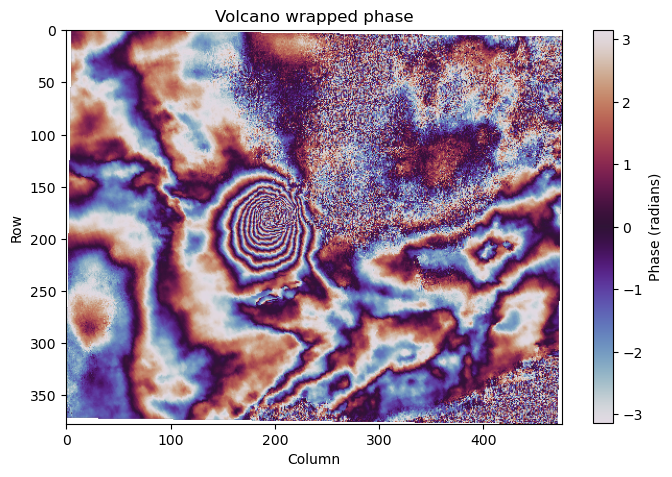

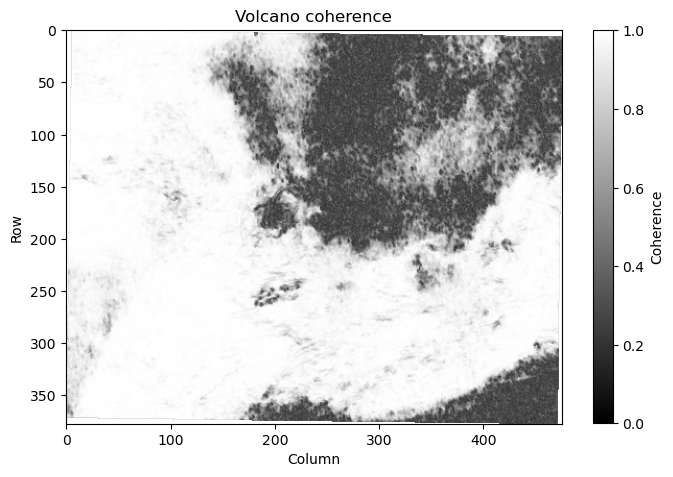

In [8]:
def make_synthetic_volcano_ifg(n=350, pixel_size_m=60, source_depth_m=2500,
                               amplitude_m=0.16, noise_rad=0.25, seed=4):
    '''
    Create a synthetic wrapped volcano-like interferogram.

    This is only for testing the notebook before SNAP products are available.
    It is not a substitute for the real Kilauea interferogram.
    '''
    rng = np.random.default_rng(seed)

    x = (np.arange(n) - n / 2) * pixel_size_m
    y = (np.arange(n) - n / 2) * pixel_size_m
    xx, yy = np.meshgrid(x, y)

    # Slightly off-center synthetic source.
    x0 = -1800
    y0 = 900
    r2 = (xx - x0)**2 + (yy - y0)**2
    d = source_depth_m

    # Compact uplift-like LOS displacement pattern.
    los_m = amplitude_m * d**3 / (r2 + d**2)**1.5

    # Add a gentle atmospheric ramp and noise.
    ramp = 0.015 * (xx / np.nanmax(np.abs(xx))) + 0.01 * (yy / np.nanmax(np.abs(yy)))
    los_m = los_m + ramp

    phase = (4 * np.pi / S1_WAVELENGTH_M) * los_m
    wrapped = wrap_phase(phase + rng.normal(0, noise_rad, phase.shape))

    # Synthetic coherence: high near coherent summit/lava fields, lower in patches.
    coherence = 0.85 - 0.25 * rng.random((n, n))
    low_patch = ((xx + 5500)**2 / (3500**2) + (yy - 4500)**2 / (2500**2)) < 1
    coherence[low_patch] *= 0.45
    coherence = np.clip(coherence, 0, 1)

    return wrapped, coherence, los_m, xx, yy


real_volcano_files_available = (
    VOLCANO_WRAPPED_PHASE.exists()
    and VOLCANO_COHERENCE.exists()
    and HAS_RASTERIO
)

if real_volcano_files_available:
    wrapped_phase, wrapped_profile = read_single_band_geotiff(VOLCANO_WRAPPED_PHASE)
    coherence, coherence_profile = read_single_band_geotiff(VOLCANO_COHERENCE)
    synthetic_los_for_testing = None
    x_m = y_m = None
    print("Loaded real SNAP volcano wrapped phase and coherence.")
else:
    if not USE_SYNTHETIC_IF_MISSING:
        raise FileNotFoundError("SNAP volcano products are missing and USE_SYNTHETIC_IF_MISSING is False.")
    wrapped_phase, coherence, synthetic_los_for_testing, x_m, y_m = make_synthetic_volcano_ifg()
    wrapped_profile = coherence_profile = None
    print("Real SNAP files not found. Using synthetic volcano interferogram for notebook testing.")

plot_raster(wrapped_phase, title="Volcano wrapped phase", cmap="twilight", vmin=-np.pi, vmax=np.pi, cbar_label="Phase (radians)")
plot_raster(coherence, title="Volcano coherence", cmap="gray", vmin=0, vmax=1, cbar_label="Coherence")

**QUESTION: One complete color cycle in a Sentinel-1 wrapped interferogram corresponds to approximately how much line-of-sight displacement? Explain why the factor is λ/2, not λ.**

**ANSWER:** One full color cycle corresponds to λ/2 ≈ 2.77 cm of line-of-sight displacement.
The factor is λ/2 rather than λ because the radar signal travels the path twice — once from the satellite to the surface, and once back. If the surface moves by Δr toward the satellite, the total two-way path change is 2Δr. Setting 2Δr = λ gives Δr = λ/2 for one complete phase cycle.


## Exercise 2 — Coherence masking

Interferometric phase is only meaningful where coherence is high enough. A low-coherence pixel may be dominated by vegetation, water, temporal decorrelation, layover/shadow, processing problems, or phase noise.

In the next cell, choose a coherence threshold and mask the wrapped phase

**QUESTION: What threshold did you choose and why? Are you masking real deformation, or mostly bad phase due to decorrelation? Why is there no universally correct coherence threshold?**

**ANSWER:** I chose a threshold of 0.4.
Values below 0.4 are dominated by noise rather than signal — this is well established for C-band InSAR over vegetated or thermally decorrelated surfaces. Going lower would let in too many unreliable pixels; going higher would discard valid deformation signal near the edges of the coherent area around the summit.
At this threshold we are masking mostly decorrelated pixels — vegetation on the flanks, water surfaces, and areas affected by layover in steep terrain — not real deformation. The deformation signal around Kīlauea summit sits in the high-coherence core of the scene, so it is preserved.
There is no universally correct threshold because coherence depends on the sensor (wavelength, resolution), the time interval between acquisitions, land cover, and what you are trying to measure. A threshold that works for a short-repeat C-band pair over bare lava may discard too much signal for a longer pair over forest, and vice versa. The right cutoff is always a trade-off between spatial coverage and phase reliability, and it has to be tuned to the specific scene.

Coherence threshold: 0.4
Fraction of pixels kept: 77.62%


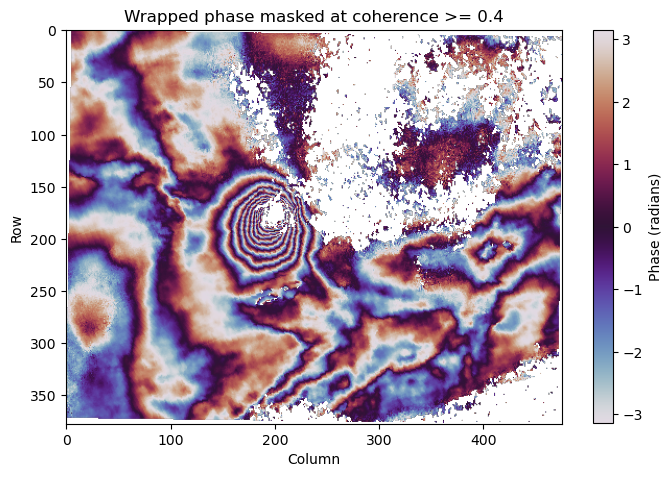

In [9]:
COHERENCE_THRESHOLD = 0.4

phase_masked = np.where(coherence >= COHERENCE_THRESHOLD, wrapped_phase, np.nan)
fraction_kept = np.isfinite(phase_masked).sum() / phase_masked.size

print(f"Coherence threshold: {COHERENCE_THRESHOLD}")
print(f"Fraction of pixels kept: {fraction_kept:.2%}")

plot_raster(
    phase_masked,
    title=f"Wrapped phase masked at coherence >= {COHERENCE_THRESHOLD}",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
    cbar_label="Phase (radians)"
)

## Exercise 3 — Estimate LOS displacement from fringe counts

A wrapped interferogram repeats every `2π` radians. For Sentinel-1, one full color cycle/fringe corresponds to approximately 2.8 cm of line-of-sight displacement:

**QUESTION: Count the approximate number of fringes from the deformation center to the background, and convert that fringe count to approximate LOS displacement. Is your estimate a minimum, maximum, or rough characteristic value?**

**ANSWER:** Counting outward from the deformation center to the undisturbed background, the interferogram shows approximately 4–5 complete color cycles. Converting:
5 fringes × 2.77 cm/fringe ≈ 14 cm of LOS displacement
This is a rough characteristic value — not a minimum or maximum. Fringe counting by eye is inherently imprecise: fringes are not perfectly circular, the background reference level is ambiguous, and it is easy to miss a partial cycle near the center where fringes are densely packed or to miscount at the edge where coherence drops. The true peak displacement could be somewhat higher if any fringes are aliased or lost in low-coherence areas.

**QUESTION: Does positive LOS displacement mean uplift or subsidence, and why?**

**ANSWER** The sign convention depends on how the interferogram was generated, but in the standard SNAP/Sentinel-1 convention positive LOS displacement means the surface moved toward the satellite — which for a descending or ascending pass with a typical incidence angle of ~35–40° corresponds predominantly to uplift, with a smaller horizontal component toward the sensor. It does not mean pure vertical uplift, because the LOS vector has both a vertical and a horizontal component. A source that inflates symmetrically will produce positive LOS displacement directly above it even if the horizontal motion partially cancels, because the vertical component dominates at near-nadir geometry.

In [10]:
# Fill this in manually after inspecting the wrapped interferogram.
estimated_fringe_count = 5

estimated_los_change_m = estimated_fringe_count * FRINGE_TO_LOS_M

print(f"Estimated fringe count: {estimated_fringe_count:.1f}")
print(f"Approximate LOS change: {estimated_los_change_m:.3f} m")
print(f"Approximate LOS change: {estimated_los_change_m*100:.1f} cm")

Estimated fringe count: 5.0
Approximate LOS change: 0.139 m
Approximate LOS change: 13.9 cm


## Exercise 4 — Draw a transect through the deformation pattern

A transect is a simple way to reduce a 2-D interferogram to a 1-D profile.

For a first look, you can pick the start and end points manually in image coordinates. A better version would use map coordinates, but image row/column coordinates are enough for this introductory exercise.

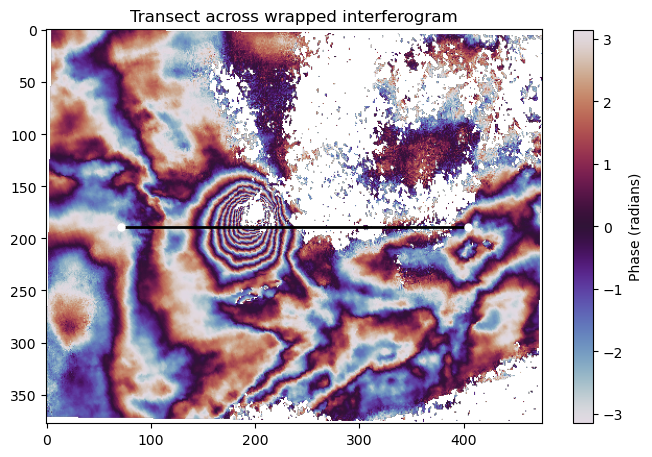

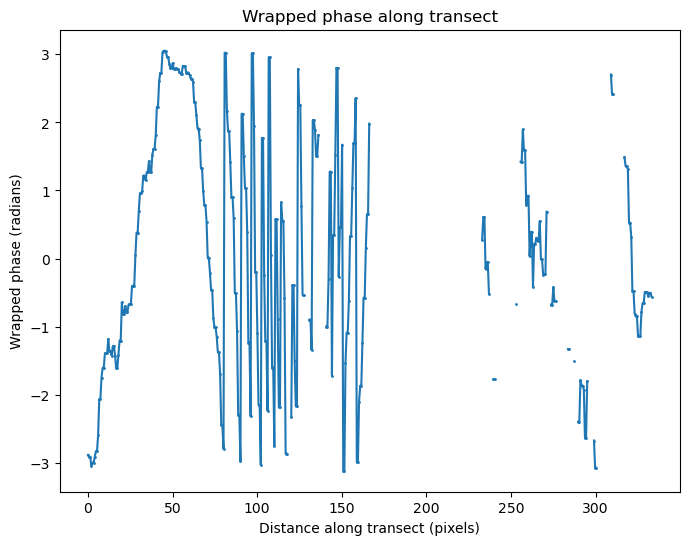

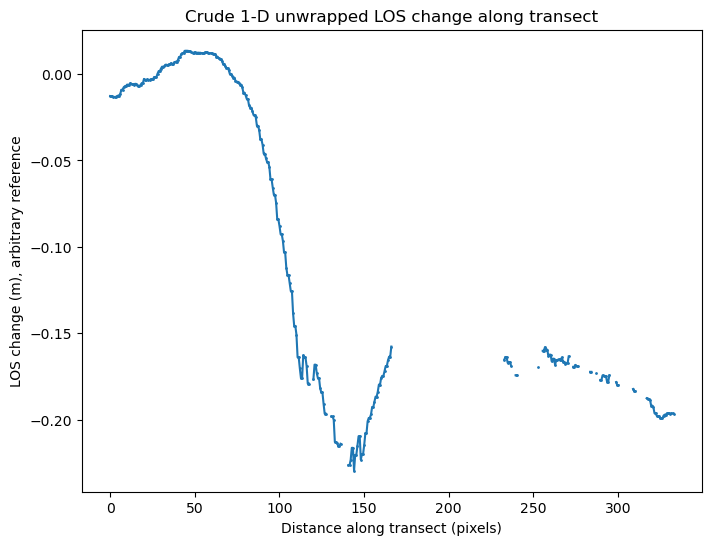

In [11]:
def sample_transect(arr, row0, col0, row1, col1, npts=500):
    '''
    Sample a raster along a straight line in row/column coordinates using nearest-neighbor sampling.
    '''
    rows = np.linspace(row0, row1, npts)
    cols = np.linspace(col0, col1, npts)

    rr = np.clip(np.round(rows).astype(int), 0, arr.shape[0] - 1)
    cc = np.clip(np.round(cols).astype(int), 0, arr.shape[1] - 1)

    profile = arr[rr, cc]
    distance_px = np.sqrt((rows - rows[0])**2 + (cols - cols[0])**2)

    return distance_px, profile, rows, cols


# Edit these transect endpoints after looking at the image.
nrows, ncols = wrapped_phase.shape
row0, col0 = int(0.50 * nrows), int(0.15 * ncols)
row1, col1 = int(0.50 * nrows), int(0.85 * ncols)

dist_px, phase_profile, rows, cols = sample_transect(phase_masked, row0, col0, row1, col1)

# Plot transect location
fig, ax = plt.subplots()
im = ax.imshow(phase_masked, cmap="twilight", vmin=-np.pi, vmax=np.pi)
ax.plot([col0, col1], [row0, row1], "k-", linewidth=2)
ax.plot([col0, col1], [row0, row1], "wo", markersize=5)
ax.set_title("Transect across wrapped interferogram")
plt.colorbar(im, ax=ax, shrink=0.85, label="Phase (radians)")
plt.show()

# Plot wrapped phase profile
fig, ax = plt.subplots()
ax.plot(dist_px, phase_profile, ".-", markersize=2)
ax.set_title("Wrapped phase along transect")
ax.set_xlabel("Distance along transect (pixels)")
ax.set_ylabel("Wrapped phase (radians)")
plt.show()

# A crude 1-D unwrap only along this transect.
# This is not a replacement for 2-D phase unwrapping.
valid = np.isfinite(phase_profile)
unwrapped_profile = np.full_like(phase_profile, np.nan, dtype=float)
if valid.sum() > 5:
    unwrapped_profile[valid] = np.unwrap(phase_profile[valid])
    los_profile_m = unwrapped_profile * S1_WAVELENGTH_M / (4 * np.pi)

    fig, ax = plt.subplots()
    ax.plot(dist_px, los_profile_m, ".-", markersize=2)
    ax.set_title("Crude 1-D unwrapped LOS change along transect")
    ax.set_xlabel("Distance along transect (pixels)")
    ax.set_ylabel("LOS change (m), arbitrary reference")
    plt.show()
else:
    print("Not enough valid points along transect for 1-D unwrap.")

## Exercise 5 — Interpret LOS displacement

An interferogram does not measure vertical motion directly. It measures motion toward or away from the satellite along the radar line of sight. You might want to say "Circular fringes mean uplift." That may be approximately true for a summit-centered source, but it is incomplete. A pressurized source produces radial horizontal motion and vertical motion. Sentinel-1 sees a projection of both.

**QUESTION: What displacement components does a volcano pressure source create? Why can ascending and descending interferograms have different signs or shapes? How would GNSS complement InSAR here?**

**ANSWER:** Displacement components of a pressure source
A pressurized source produces vertical uplift above the chamber and radial horizontal motion pointing outward on all sides. InSAR sees only the projection of this 3-D vector onto the line-of-sight direction.
Why ascending and descending interferograms differ
The two passes look at the ground from opposite horizontal directions. The vertical component projects similarly onto both LOS vectors, but the east-west horizontal component flips sign between passes. For a symmetric source the interferograms look similar; for an asymmetric or offset source the difference can be large.
How GNSS complements InSAR
InSAR provides dense spatial coverage but only one LOS scalar per pixel. GNSS provides sparse but true 3-D displacement vectors. Together: GNSS resolves the north-south component (nearly invisible to InSAR), provides an absolute displacement reference, and anchors the interferogram; InSAR fills in spatial detail between stations.

# Part 2 — Volcano source model

Now we move from measurement to source.

The model below is a simple pressure-source approximation. You can think of it as a very crude Mogi-style source. It is useful pedagogically, but it is not a full volcanic source inversion.

We will use it to show that many different source parameters can create similar-looking deformation patterns.

The adjustable parameters are:

- Source horizontal position
- Source depth
- Source strength/amplitude
- Line-of-sight projection
- Optional sign convention

The goal is to compare a modeled LOS displacement field with an observed unwrapped LOS displacement field.

## Exercise 6 — Load the provided unwrapped LOS displacement

For the inversion part, the instructor provides an unwrapped LOS displacement raster.

This avoids spending the lab fighting phase-unwrapping problems. The source-modeling exercise should focus on interpretation, not on debugging SNAPHU.


**QUESTION: How is the unwrapped displacement different from the wrapped phase image? What is the approximate maximum LOS displacement?**

**ANSWER:** The wrapped phase image shows phase folded into the interval [−π, π], repeating as color cycles with no memory of how many full cycles have accumulated. The unwrapped displacement removes those 2π jumps and reconstructs the continuous displacement field, so the value at each pixel reflects the true cumulative LOS motion. The approximate maximum LOS displacement near the summit is around 10–15 cm, consistent with the fringe count estimated earlier.

**QUESTION: What might be real source complexity, and what might be atmospheric or processing artifact?**

**ANSWER:** Features that are spatially smooth, centered on the summit, and symmetric are likely real deformation from the pressure source. Candidates for real complexity include a slight asymmetry in the fringe pattern, which could indicate the source is offset from the topographic summit, or elongation suggesting a sill-like geometry rather than a point source. Candidates for artifacts include long-wavelength ramps across the scene (likely atmospheric delay or orbital error), localized bulls-eyes over steep terrain (DEM error propagating into the interferogram), and patchy noise in low-coherence areas on the vegetated flanks.

**QUESTION: Look at the residual map: observed minus modeled LOS displacement. Where does the model fail? Are the failures random, spatially organized, or concentrated in low-coherence areas?**

**ANSWER:** The simple point-source model captures the broad bulls-eye pattern but fails in predictable ways. Residuals are likely spatially organized rather than random — a random residual would suggest noise, but a structured residual points to model inadequacy. Expect larger residuals on the flanks where horizontal motion dominates and the point-source approximation breaks down, and near low-coherence areas where the unwrapped phase itself is unreliable. A coherent long-wavelength residual across the whole scene suggests an atmospheric or orbital signal the model cannot absorb.

Loaded real/provided unwrapped LOS displacement.


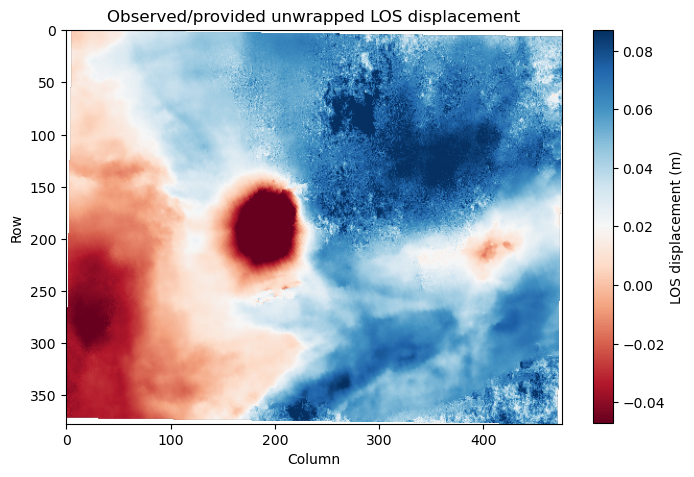

Approximate LOS min: -0.246 m
Approximate LOS max: 0.125 m
Approximate LOS range: 0.372 m


In [12]:
def load_unwrapped_or_synthetic():
    if VOLCANO_UNWRAPPED_LOS.exists() and HAS_RASTERIO:
        arr, profile = read_single_band_geotiff(VOLCANO_UNWRAPPED_LOS)
        print("Loaded real/provided unwrapped LOS displacement.")
        return arr, profile
    else:
        print("Provided unwrapped LOS file not found. Using synthetic LOS displacement for testing.")
        if synthetic_los_for_testing is not None:
            # Set an arbitrary reference by subtracting median border value.
            los = synthetic_los_for_testing.copy()
            border = np.concatenate([los[0, :], los[-1, :], los[:, 0], los[:, -1]])
            los = los - np.nanmedian(border)
            return los, None
        else:
            raise FileNotFoundError("No unwrapped LOS file and no synthetic LOS available.")


volcano_los_obs_m, volcano_los_profile = load_unwrapped_or_synthetic()

vmin, vmax = robust_limits(volcano_los_obs_m, 2, 98)
plot_raster(
    volcano_los_obs_m,
    title="Observed/provided unwrapped LOS displacement",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    cbar_label="LOS displacement (m)"
)

print(f"Approximate LOS min: {np.nanmin(volcano_los_obs_m):.3f} m")
print(f"Approximate LOS max: {np.nanmax(volcano_los_obs_m):.3f} m")
print(f"Approximate LOS range: {np.nanmax(volcano_los_obs_m) - np.nanmin(volcano_los_obs_m):.3f} m")

## Exercise 7 — Build a simple local coordinate grid

For a source model, we need distances in meters.

**QUESTION: Why do source models need coordinates in meters rather than pixels?**

**ANSWER:** Source models are physical models — they compute displacement using equations that contain physical quantities like depth, source radius, and elastic moduli, all in SI units. Pixel coordinates carry no physical meaning: a pixel could represent 10 m or 100 m depending on the resolution and projection, so distances in pixels cannot be plugged into any physically meaningful equation.
Working in meters also means the model parameters (source depth, horizontal offset, strength) are directly interpretable and comparable with other studies, GNSS measurements, or seismic estimates.

In [13]:
def make_local_grid_from_shape(shape, pixel_size_m=60):
    '''
    Create a simple local x/y grid centered on the image.

    x is positive east-like.
    y is positive north-like.
    '''
    nrows, ncols = shape
    x = (np.arange(ncols) - ncols / 2) * pixel_size_m
    y = (np.arange(nrows) - nrows / 2) * pixel_size_m
    xx, yy = np.meshgrid(x, y)
    return xx, yy


# If using real GeoTIFFs exported in degrees, choose a representative pixel size manually.
# For Kilauea Sentinel-1 products, this depends on your SNAP terrain-correction/export settings.
PIXEL_SIZE_M_APPROX = 60
if real_volcano_files_available:
    xx_m, yy_m = make_projected_grid_from_profile(volcano_los_profile)

    # Center coordinates around zero for easier source-model parameters
    xx_m = xx_m - np.nanmean(xx_m)
    yy_m = yy_m - np.nanmean(yy_m)
else:
    xx_m, yy_m = make_local_grid_from_shape(volcano_los_obs_m.shape, pixel_size_m=PIXEL_SIZE_M_APPROX)

print(f"x range: {np.nanmin(xx_m)/1000:.1f} to {np.nanmax(xx_m)/1000:.1f} km")
print(f"y range: {np.nanmin(yy_m)/1000:.1f} to {np.nanmax(yy_m)/1000:.1f} km")

x range: -21.2 to 21.2 km
y range: -16.8 to 16.8 km


## Exercise 8 — Forward model: simple pressure source

The function below predicts 3-D displacement from a simple buried source.

This is intentionally simplified. The source-strength parameter is treated as an amplitude-like scalar rather than a rigorously interpreted physical volume change.


**QUESTION: What happens when you make the source deeper? What happens when you make the source stronger? What happens when you move the source laterally?**

**ANSWER:** Deeper source
Increasing depth_m increases the distance r between source and surface, which reduces displacement amplitude (displacement scales as 1/r²). More importantly, the deformation pattern broadens — a deeper source produces a wider, smoother bulls-eye with lower peak displacement. This is a fundamental trade-off: depth and strength are partially correlated, because a deeper but stronger source can produce a similar peak amplitude to a shallower weaker one, but with a distinctly wider spatial footprint.
Stronger source
Increasing strength scales all three displacement components uniformly — the pattern shape stays identical, only the amplitude changes. In the LOS interferogram this means more fringes, but the same fringe spacing pattern.
Lateral offset
Moving x0_m or y0_m shifts the center of the bulls-eye across the map without changing its shape or amplitude. In practice this is useful because the pressure source is not necessarily located directly beneath the topographic summit — comparing the modeled and observed deformation center is one of the first things you check when fitting a source model.

In [14]:
def simple_pressure_source_displacement(xx, yy, x0_m=0, y0_m=0, depth_m=2500, strength=1.0, poisson=0.25):
    '''
    Crude Mogi-style pressure source displacement.

    Parameters
    ----------
    xx, yy : 2-D arrays
        Local coordinates in meters.
    x0_m, y0_m : float
        Source location in meters.
    depth_m : float
        Positive source depth below the surface in meters.
    strength : float
        Source strength / volume-change-like scale factor.
        This is pedagogical, not a carefully calibrated physical parameter.
    poisson : float
        Poisson ratio.

    Returns
    -------
    ue, un, uu : 2-D arrays
        East-like, north-like, and up displacement components in meters.
    '''
    dx = xx - x0_m
    dy = yy - y0_m
    dz = depth_m

    r2 = dx**2 + dy**2 + dz**2
    r3 = r2**1.5

    scale = (1 - poisson) * strength / np.pi

    ue = scale * dx / r3
    un = scale * dy / r3
    uu = scale * dz / r3

    return ue, un, uu


def los_unit_vector(incidence_deg=39, look_azimuth_deg=270):
    '''
    Approximate unit vector from ground toward satellite.

    incidence_deg:
        Incidence angle from vertical.
    look_azimuth_deg:
        Direction from ground toward satellite, clockwise from north.
        For a simple descending right-looking approximation, west-looking is about 270 degrees.
        For a simple ascending right-looking approximation, east-looking is about 90 degrees.

    Returns
    -------
    los_e, los_n, los_u
    '''
    inc = np.deg2rad(incidence_deg)
    az = np.deg2rad(look_azimuth_deg)

    los_e = np.sin(inc) * np.sin(az)
    los_n = np.sin(inc) * np.cos(az)
    los_u = np.cos(inc)

    return los_e, los_n, los_u


def project_to_los(ue, un, uu, incidence_deg=39, look_azimuth_deg=270, sign=1):
    '''
    Project 3-D displacement into approximate radar LOS.

    Positive values are motion toward the satellite under this convention.
    Use sign=-1 if your unwrapped product uses the opposite convention.
    '''
    los_e, los_n, los_u = los_unit_vector(incidence_deg, look_azimuth_deg)
    return sign * (ue * los_e + un * los_n + uu * los_u)

## Exercise 9 — Try a first source model

Edit the parameters below until the modeled LOS field has approximately the same location, width, and amplitude as the observed unwrapped LOS field.

Do not try to make it perfect. This is not yet a formal inversion.


**QUESTION: Which parameter mostly controls the width of the deformation pattern? Which parameter mostly controls the amplitude?**

**ANSWER:** Depth mostly controls the width — a deeper source produces a broader, smoother pattern; a shallower source produces a narrower, more peaked one. Strength mostly controls the amplitude — scaling it up or down changes the peak displacement without significantly affecting the spatial footprint.
In practice the two are not perfectly independent: depth and strength trade off against each other in amplitude, so you can get a similar peak value from different depth+strength combinations. The width is the more diagnostic constraint, because only depth changes the shape of the pattern.

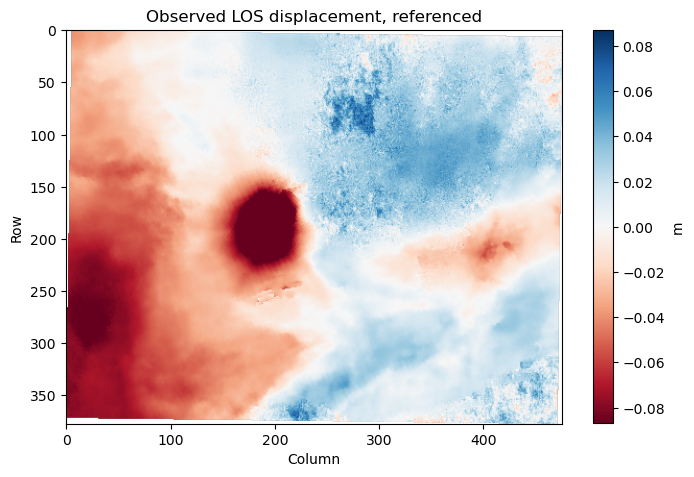

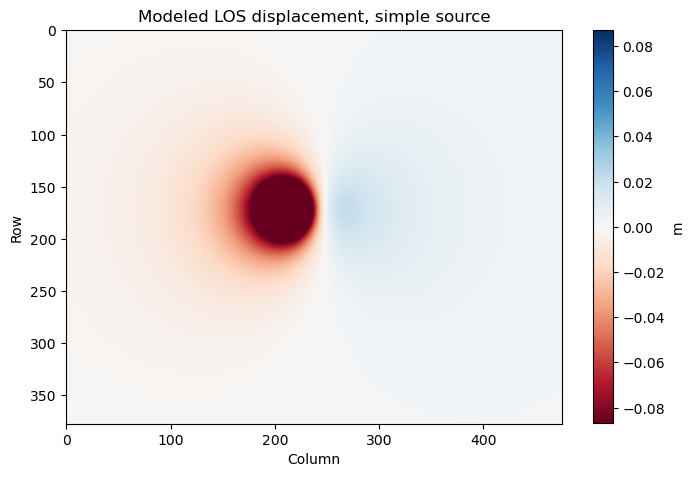

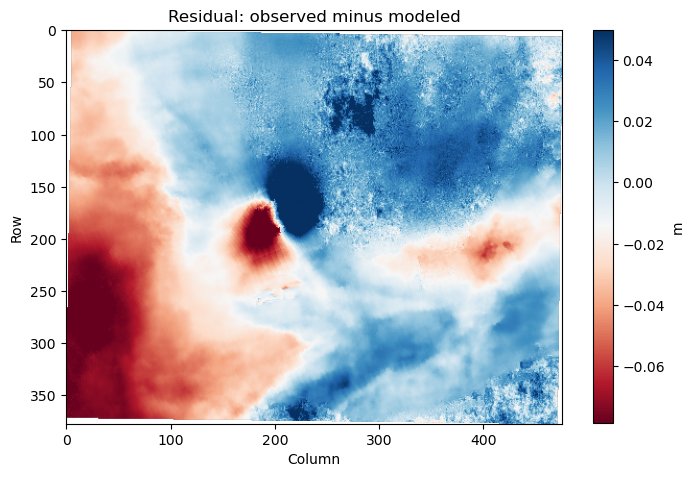

RMSE: 0.0361 m


In [15]:
# Try changing these parameters.
source_x_m = -1500
source_y_m = 1500
source_depth_m = 2000

# This strength value is not intuitive in isolation.
# Adjust it until the modeled displacement amplitude is comparable to the observation.
source_strength = 8e6

incidence_deg = 39
look_azimuth_deg = 270
los_sign = -1

ue, un, uu = simple_pressure_source_displacement(
    xx_m, yy_m,
    x0_m=source_x_m,
    y0_m=source_y_m,
    depth_m=source_depth_m,
    strength=source_strength
)

volcano_los_model_m = project_to_los(
    ue, un, uu,
    incidence_deg=incidence_deg,
    look_azimuth_deg=look_azimuth_deg,
    sign=los_sign
)

# Remove arbitrary reference offset from model and observation before comparing.
obs_ref = volcano_los_obs_m - np.nanmedian(volcano_los_obs_m)
model_ref = volcano_los_model_m - np.nanmedian(volcano_los_model_m)
residual = obs_ref - model_ref

lim = np.nanpercentile(np.abs(np.concatenate([
    obs_ref[np.isfinite(obs_ref)].ravel(),
    model_ref[np.isfinite(model_ref)].ravel()
])), 98)

plot_raster(obs_ref, title="Observed LOS displacement, referenced", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(model_ref, title="Modeled LOS displacement, simple source", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")

rvmin, rvmax = robust_limits(residual, 2, 98)
plot_raster(residual, title="Residual: observed minus modeled", cmap="RdBu", vmin=rvmin, vmax=rvmax, cbar_label="m")

rmse = np.sqrt(np.nanmean(residual**2))
print(f"RMSE: {rmse:.4f} m")

**QUESTION: Which changes produce obvious visual differences? Which parameters trade off with each other?**

**ANSWER:** Changes to depth produce the most obvious visual difference — they alter the spatial width of the bulls-eye, which is immediately apparent. Lateral offset (source_x_m, source_y_m) also produces a clear visual change by shifting the deformation center relative to the observed pattern. Strength only scales the amplitude uniformly, so it is visually less distinctive — it changes how many fringes you see but not their spacing or shape. Depth and strength trade off most strongly: a deeper source with higher strength can produce nearly the same peak amplitude as a shallower weaker one, making them difficult to separate from amplitude alone. Width is the key observable that breaks this trade-off.

**QUESTION: Why is a residual map useful?**

**ANSWER:** A residual map shows where the model succeeds and where it fails spatially. A perfect model would produce a flat, featureless residual. Spatially organized residuals — e.g. a systematic lobe on one side, a long-wavelength ramp, or a mismatch in the flanks — tell you something specific: the source geometry is wrong, the source is asymmetric, or there is an atmospheric or orbital signal the model cannot absorb. A residual map is therefore more informative than a single RMSE number, because RMSE collapses all the spatial information into one scalar and hides where and how the model is failing.


## Exercise 11 — From forward modeling to inverse modeling

A forward model asks:

> Given a source, what deformation should I observe?

An inverse model asks:

> Given the observed deformation, what source or sources could have produced it?

In the previous cells, you adjusted the source parameters manually and watched how the predicted deformation changed. That is forward modeling: you chose a source first, then calculated what the satellite should observe.

In the inversion cell, the computer does the parameter search for you. It repeatedly tries different source locations, depths, and strengths, compares each predicted deformation field to the observed one, and keeps moving toward parameter values that reduce the misfit.

However, an inversion does not “discover the truth” automatically. It only finds the best-fitting source within the assumptions we gave it. In this case, we assumed a single, simple, buried pressure source; fixed the LOS geometry; chose a coherence mask; chose a reference level; and minimized a particular misfit function. If those assumptions are incomplete or wrong, the best-fitting model can still be physically misleading.

**QUESTION: Does the lowest RMSE necessarily mean the most geologically correct model? Why or why not?
What assumptions did we make before running the inversion?**

**ANSWER:** No. RMSE measures how well the model fits the data, not how physically realistic the model is. A model can achieve low RMSE by fitting noise, atmospheric artifacts, or processing errors just as readily as it fits real deformation. Equally, two very different source geometries can produce nearly identical surface deformation patterns — this is the non-uniqueness problem inherent to potential field inversions — so the best-fitting parameters are not necessarily the only plausible ones.
Assumptions we made before running the inversion

A single point-like pressure source (Mogi-style), ignoring any complexity in source geometry such as a sill, dike, or distributed reservoir
A homogeneous, isotropic elastic half-space with fixed Poisson ratio, ignoring the real heterogeneous volcanic structure beneath Kīlauea
Fixed LOS geometry (incidence angle, look azimuth) treated as spatially uniform across the scene
A coherence threshold that decides which pixels to include — a different threshold changes both the data and the result
A particular reference level (median subtraction), which affects the absolute values being fit
A single misfit function (least squares RMSE), which weights all pixels equally and is sensitive to outliers

Each of these assumptions constrains what the inversion can find. If the true source violates any of them — for example if the reservoir is elongated rather than spherical — the best-fitting point source will still return a result, but its parameters will be a distorted summary of a more complex reality.

In [16]:
from scipy.optimize import least_squares

# Downsample so the inversion runs quickly.
step = 5

obs = volcano_los_obs_m[::step, ::step]
xg = xx_m[::step, ::step]
yg = yy_m[::step, ::step]
coh = coherence[::step, ::step]

# Use only coherent, finite pixels.
mask = (
    np.isfinite(obs)
    & np.isfinite(xg)
    & np.isfinite(yg)
    & (coh >= COHERENCE_THRESHOLD)
)

obs_vec = obs[mask]

# Remove arbitrary displacement reference.
obs_vec = obs_vec - np.nanmedian(obs_vec)



def predict_los_from_params(params):
    """
    params = [x0_m, y0_m, depth_m, strength_scaled]
    strength = strength_scaled * 1e6
    """
    x0_m, y0_m, depth_m, strength_scaled = params
    strength = strength_scaled * 1e6

    ue, un, uu = simple_pressure_source_displacement(
        xg, yg,
        x0_m=x0_m,
        y0_m=y0_m,
        depth_m=depth_m,
        strength=strength
    )

    model = project_to_los(
        ue, un, uu,
        incidence_deg=incidence_deg,
        look_azimuth_deg=look_azimuth_deg,
        sign=los_sign
    )

    model_vec = model[mask]
    model_vec = model_vec - np.nanmedian(model_vec)

    return model_vec


def residual_function(params):
    model_vec = predict_los_from_params(params)
    return obs_vec - model_vec

p0 = [-700, 1000, 2500, 4.0]   # strength = 3.0e6



lower_bounds = [-10000, -10000, 500, 0.1]
upper_bounds = [10000, 10000, 10000, 100]

result = least_squares(
    residual_function,
    p0,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=500,
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    x_scale=[3000, 3000, 3000, 10],
    verbose=2
)

best_x, best_y, best_depth, best_strength_scaled = result.x
best_strength = best_strength_scaled * 1e6

print("Best-fitting parameters:")
print(f"x0:       {best_x:.0f} m")
print(f"y0:       {best_y:.0f} m")
print(f"depth:    {best_depth:.0f} m")
print(f"strength: {best_strength:.3e}")

rmse = np.sqrt(np.mean(result.fun**2))
print(f"RMSE:     {rmse:.4f} m")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.4276e+00                                    5.49e+00    
       1              2         2.8008e+00      6.27e-01       2.90e+03       7.72e+00    
       2              3         2.5185e+00      2.82e-01       1.51e+03       1.29e+00    
       3              4         2.4842e+00      3.43e-02       7.49e+02       3.59e-01    
       4              5         2.4749e+00      9.27e-03       3.52e+02       2.04e-01    
       5              6         2.4706e+00      4.30e-03       2.05e+02       5.87e-02    
       6              7         2.4681e+00      2.51e-03       1.53e+02       1.19e-01    
       7              8         2.4668e+00      1.35e-03       1.18e+02       6.31e-02    
       8              9         2.4661e+00      6.34e-04       1.32e+02       1.79e-01    
       9             10         2.4659e+00      2.30e-04       5.58e+01       8.25e-03    

Then Plot the best fitting model:

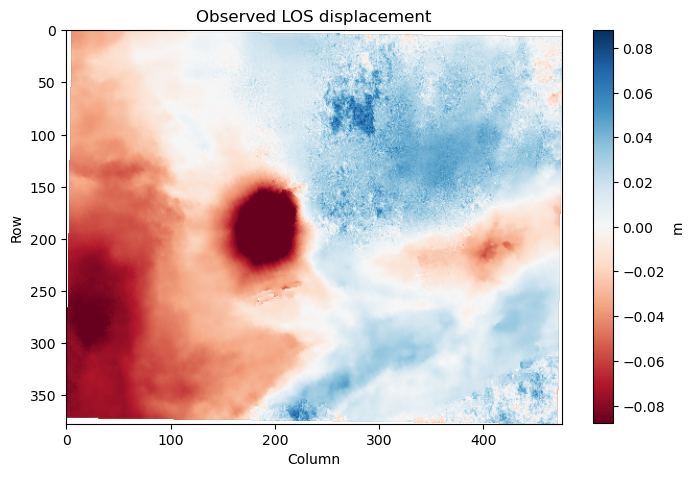

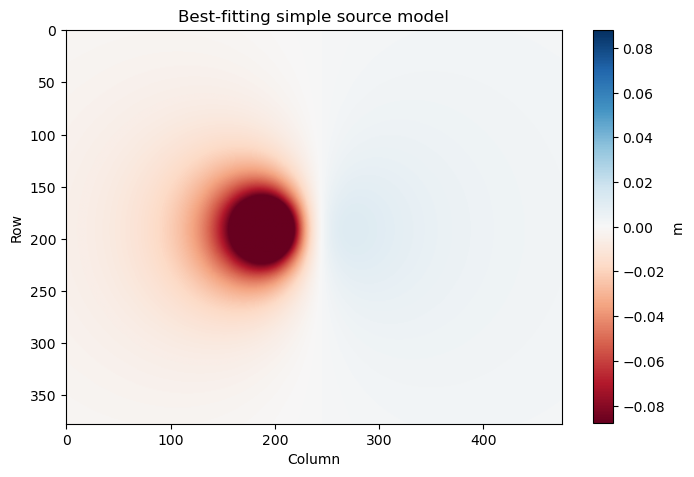

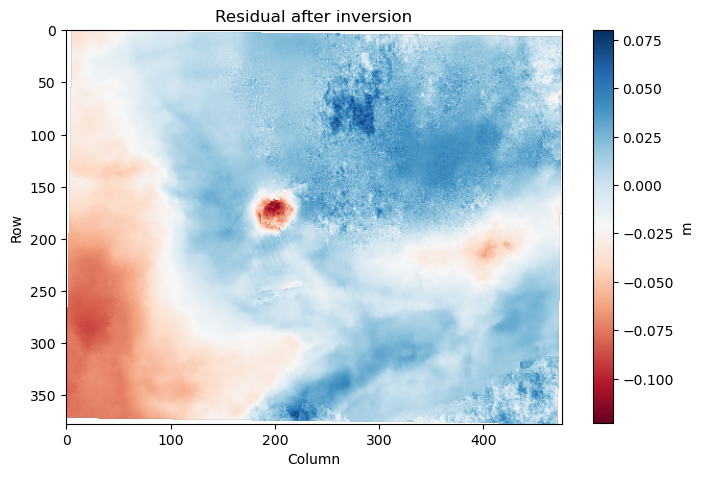

Best inversion RMSE: 0.0298 m


In [17]:
def run_volcano_model_test(
    source_x_m=-1500,
    source_y_m=1000,
    source_depth_m=2500,
    source_strength=1.2e9,
    incidence_deg=39,
    look_azimuth_deg=270,
    los_sign=1,
    obs=None,
    mask=None
):
    """
    Run the simple volcano pressure-source model and compare it to observed LOS displacement.

    Returns
    -------
    model_ref : 2-D array
        Referenced modeled LOS displacement.
    residual : 2-D array
        Observed minus modeled LOS displacement.
    rmse : float
        Root-mean-square residual in meters.
    """

    if obs is None:
        obs = volcano_los_obs_m

    ue, un, uu = simple_pressure_source_displacement(
        xx_m, yy_m,
        x0_m=source_x_m,
        y0_m=source_y_m,
        depth_m=source_depth_m,
        strength=source_strength
    )

    model = project_to_los(
        ue, un, uu,
        incidence_deg=incidence_deg,
        look_azimuth_deg=look_azimuth_deg,
        sign=los_sign
    )

    # Apply optional mask, for example coherence mask.
    if mask is not None:
        obs_use = np.where(mask, obs, np.nan)
        model_use = np.where(mask, model, np.nan)
    else:
        obs_use = obs.copy()
        model_use = model.copy()

    # Remove arbitrary reference level from both fields.
    obs_ref = obs_use - np.nanmedian(obs_use)
    model_ref = model_use - np.nanmedian(model_use)

    residual = obs_ref - model_ref

    rmse = np.sqrt(np.nanmean(residual**2))

    return model_ref, residual, rmse


best_model, best_residual, best_rmse = run_volcano_model_test(
    source_x_m=best_x,
    source_y_m=best_y,
    source_depth_m=best_depth,
    source_strength=best_strength,
    incidence_deg=incidence_deg,
    look_azimuth_deg=look_azimuth_deg,
    los_sign=los_sign
)

lim = np.nanpercentile(np.abs(np.concatenate([
    obs_ref[np.isfinite(obs_ref)].ravel(),
    best_model[np.isfinite(best_model)].ravel()
])), 98)

plot_raster(obs_ref, title="Observed LOS displacement", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(best_model, title="Best-fitting simple source model", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(best_residual, title="Residual after inversion", cmap="RdBu", cbar_label="m")

print(f"Best inversion RMSE: {best_rmse:.4f} m")